# LOGISTIC REGRESSION (ML Approach)- WEC 2026
## CLEANED DATA + FEATURE ENGINEERING (RATIOS + PASSES TOP THIRD)
## Fixture-level train/test split + Stratified Group K-Fold CV

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    RocCurveDisplay,
)

In [30]:
# Set the data working directory
DATA_PATH = "/Users/teo/Library/CloudStorage/GoogleDrive-t.leprovost@student.uw.edu.pl/My Drive/Studies_UW/Warsaw_Econometrics_Challenge"
os.chdir(DATA_PATH)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Row filtering:
- Remove the position goalkeeper for the training?
- Remove all the lines where the player was not on the pitch the full quarter?

Column filtering:
- (Checkpoint, checkpoint_period, checkpoint_min could be redundant for the model)?
- remove jersey_number? If it is used to identify the player, it's redundant for the model with player_id
Group the data in two parts:
- player behaviour
- team parameters (home/away, formation, position on the pitch)

# 1. LOAD DATA

In [31]:
quarters_1 = pd.read_csv("EDA2/features/all_engineered_features.csv")
quarters_2 = pd.read_csv("data/players_quarters_final_feature_engineered_v3.csv")

print(quarters_1.shape)
print(quarters_2.shape)

(3486, 74)
(3114, 51)


# 2. MERGE DATA

In [32]:
# Merge by intersection, remove duplicates, export
quarters = quarters_1.merge(quarters_2, left_index=True, right_index=True)
quarters = quarters.loc[:, ~quarters.columns.duplicated()]
quarters.to_csv('data/all_data.csv', index=False)

print(f"Merged shape: {quarters.shape}")

Merged shape: (3114, 125)


# 3. FEATURE SELECTION

In [33]:
# Auto-detect behavioral features (last15, cumul, ratio prefixes)
behavior_features = [c for c in quarters.columns if any(c.startswith(p) for p in ["last15_", "cumul_", "ratio_"])]

# Team-level features (context, not player-dependent)
team_features = ["position", "is_home", "formation", "minute_in", "minute_out", "subbed"]

# Time feature (controls for remaining match time)
time_features = ["checkpoint_min"]

# All features combined
all_features = behavior_features + team_features + time_features

# Fill missing values in behavioral features with 0
quarters[behavior_features] = quarters[behavior_features].fillna(0)

TARGET = "scored_after"
GROUP = "fixture_id"

print(f"Features: {len(behavior_features)} behavioral + {len(team_features)} team + {len(time_features)} time = {len(all_features)} total")

Features: 49 behavioral + 6 team + 1 time = 56 total


# 4. FIXTURE-LEVEL TRAIN / TEST SPLIT

Key design decision: **split by fixture_id, not by row**.

Rationale: each fixture contributes multiple rows (up to 7 checkpoints × ~22 players = ~150 rows). A random row split would put checkpoints from the same match in both train and test, leaking match-level information. We hold out ~20% of fixtures as a true test set that the model never sees during training or CV.

In [34]:
# Stratified split: binned by positive rate to ensure balanced test set
np.random.seed(42)
fixture_stats = quarters.groupby(GROUP)[TARGET].mean().reset_index(name="pos_rate")
fixture_stats["bin"] = pd.qcut(fixture_stats["pos_rate"], q=3, labels=False, duplicates="drop")

test_fixtures = (fixture_stats.groupby("bin", group_keys=False)
                 .apply(lambda x: x.sample(frac=0.20, random_state=42))["fixture_id"].values)
train_fixtures = fixture_stats[~fixture_stats["fixture_id"].isin(test_fixtures)]["fixture_id"].values

# Create train/test dataframes
df = quarters[all_features + [TARGET, GROUP]].dropna(subset=[TARGET])
df_train = df[df[GROUP].isin(train_fixtures)]
df_test = df[df[GROUP].isin(test_fixtures)]

X_train, y_train = df_train[all_features], df_train[TARGET].astype(int)
X_test, y_test = df_test[all_features], df_test[TARGET].astype(int)
groups_train = df_train[GROUP].values  # for StratifiedGroupKFold

print(f"Train: {X_train.shape[0]} rows ({len(train_fixtures)} fixtures, {y_train.mean():.2%} positive)")
print(f"Test:  {X_test.shape[0]} rows ({len(test_fixtures)} fixtures, {y_test.mean():.2%} positive)")

# Export for R mixed effects logit
pd.DataFrame({"fixture_id": train_fixtures, "split": "train"}).to_csv("fixture_split_train.csv", index=False)
pd.DataFrame({"fixture_id": test_fixtures, "split": "test"}).to_csv("fixture_split_test.csv", index=False)
pd.DataFrame({"feature_names": all_features}).to_csv("data/train_test/feature_names.csv", index=False)

# Export raw data
X_train.to_csv("data/train_test/X_train_raw.csv", index=False)
y_train.to_csv("data/train_test/y_train_raw.csv", index=False)
X_test.to_csv("data/train_test/X_test_raw.csv", index=False)
y_test.to_csv("data/train_test/y_test_raw.csv", index=False)

Train: 2524 rows (25 fixtures, 6.42% positive)
Test:  590 rows (6 fixtures, 6.78% positive)


Balance is satisfying, train and test sets have similar positive rates.

# 5. PREPROCESSING PIPELINE

In [35]:
# Feature type separation
numeric_features = behavior_features + time_features + ["minute_in", "minute_out"]
categorical_features = ["position", "formation"]
boolean_features = ["is_home", "subbed"]

# Build preprocessing + model pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_features),
    ("bool", "passthrough", boolean_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=42)),
])

# Cross-validation on train set (StratifiedGroupKFold respects fixture boundaries)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_oof = cross_val_predict(pipeline, X_train, y_train, cv=cv, groups=groups_train, method="predict_proba")[:, 1]
y_pred_oof = (y_prob_oof >= 0.5).astype(int)

# Train final model
pipeline.fit(X_train, y_train)

# Predictions on test set
y_prob_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

# 6. CROSS-VALIDATION ON TRAIN SET

We use **StratifiedGroupKFold**: 
- `groups=fixture_id` ensures no fixture spans two folds (no leakage)
- Stratification preserves the ~6% positive rate in each fold as best as possible

This replaces the plain StratifiedKFold used in v1/v2, which split rows randomly and could mix checkpoints from the same match across folds.

In [36]:
# CV Results (train set)
auc_cv = roc_auc_score(y_train, y_prob_oof)
bal_acc_cv = balanced_accuracy_score(y_train, y_pred_oof)

print("="*60)
print("CROSS-VALIDATION RESULTS (StratifiedGroupKFold, 5 folds)")
print("="*60)
print(f"AUC-ROC: {auc_cv:.4f} | Balanced Accuracy: {bal_acc_cv:.4f}\n")
print(classification_report(y_train, y_pred_oof, target_names=["No goal", "Goal"]))
print("Confusion Matrix:", confusion_matrix(y_train, y_pred_oof), sep="\n")

# Test Results (held-out fixtures)
auc_test = roc_auc_score(y_test, y_prob_test)
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)

print("\n" + "="*60)
print("TEST SET RESULTS (Held-out fixtures)")
print("="*60)
print(f"AUC-ROC: {auc_test:.4f} | Balanced Accuracy: {bal_acc_test:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=["No goal", "Goal"]))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred_test), sep="\n")

# Summary table
summary = pd.DataFrame({
    "Evaluation": ["CV (StratifiedGroupKFold)", "Test (held-out fixtures)"],
    "AUC-ROC": [f"{auc_cv:.4f}", f"{auc_test:.4f}"],
    "Balanced Acc": [f"{bal_acc_cv:.4f}", f"{bal_acc_test:.4f}"],
})
print(summary.to_string(index=False))

# Export predictions
test_preds = df_test[[GROUP, TARGET]].copy()
test_preds["logit_prob"] = y_prob_test
test_preds["logit_pred"] = y_pred_test
test_preds.to_csv("logit_test_predictions.csv", index=False)

CROSS-VALIDATION RESULTS (StratifiedGroupKFold, 5 folds)
AUC-ROC: 0.5998 | Balanced Accuracy: 0.5789

              precision    recall  f1-score   support

     No goal       0.95      0.69      0.80      2362
        Goal       0.09      0.46      0.16       162

    accuracy                           0.68      2524
   macro avg       0.52      0.58      0.48      2524
weighted avg       0.89      0.68      0.76      2524

Confusion Matrix:
[[1641  721]
 [  87   75]]

TEST SET RESULTS (Held-out fixtures)
AUC-ROC: 0.5555 | Balanced Accuracy: 0.5355

              precision    recall  f1-score   support

     No goal       0.94      0.67      0.78       550
        Goal       0.08      0.40      0.14        40

    accuracy                           0.65       590
   macro avg       0.51      0.54      0.46       590
weighted avg       0.88      0.65      0.74       590

Confusion Matrix:
[[369 181]
 [ 24  16]]
               Evaluation AUC-ROC Balanced Acc
CV (StratifiedGroupKFold)  0

# Already included in evaluation cell above

In [37]:
# Train on all training fixtures
pipeline.fit(X_train, y_train)

# Predict on held-out test fixtures (never seen during training or CV)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

print("=" * 55)
print("TEST SET RESULTS — Held-out fixtures")
print("=" * 55)

auc_test     = roc_auc_score(y_test, y_prob_test)
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)

print(f"AUC-ROC            : {auc_test:.4f}")
print(f"Balanced Accuracy  : {bal_acc_test:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=["No goal (0)", "Goal (1)"]))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

TEST SET RESULTS — Held-out fixtures
AUC-ROC            : 0.5555
Balanced Accuracy  : 0.5355

Classification Report (Test):
              precision    recall  f1-score   support

 No goal (0)       0.94      0.67      0.78       550
    Goal (1)       0.08      0.40      0.14        40

    accuracy                           0.65       590
   macro avg       0.51      0.54      0.46       590
weighted avg       0.88      0.65      0.74       590

Confusion Matrix (Test):
[[369 181]
 [ 24  16]]


# 8. FEATURE IMPORTANCE (coefficients)

In [38]:
# Recover feature names after one-hot encoding
cat_encoder    = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feat_names + boolean_features

# Log-odds coefficients
coefficients = pipeline.named_steps["classifier"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": all_feature_names, "coefficient": coefficients})
    .assign(abs_coef=lambda df: df["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 features by absolute coefficient (log-odds):")
print(coef_df.head(15).to_string(index=False))

Top 15 features by absolute coefficient (log-odds):
               feature  coefficient  abs_coef
            position_D    -2.539648  2.539648
       formation_4-2-4    -1.886463  1.886463
     formation_4-1-3-2    -1.780474  1.780474
       formation_5-4-1    -1.752599  1.752599
     formation_4-1-4-1     1.532113  1.532113
     formation_4-2-3-1     1.355316  1.355316
       formation_4-4-2     1.309960  1.309960
            position_M    -1.165462  1.165462
 cumul_shots_top_third     0.914426  0.914426
      ratio_peak_speed    -0.736058  0.736058
                subbed     0.649774  0.649774
         last15_passes    -0.613935  0.613935
          last15_shots    -0.580432  0.580432
ratio_passes_top_third    -0.522446  0.522446
            minute_out     0.520494  0.520494


# 9. SUMMARY COMPARISON TABLE

In [39]:
summary = pd.DataFrame({
    "Evaluation"      : ["CV (StratifiedGroupKFold)", "Test set (held-out fixtures)"],
    "AUC-ROC"         : [round(auc_cv, 4), round(auc_test, 4)],
    "Balanced Acc"    : [round(bal_acc_cv, 4), round(bal_acc_test, 4)],
})
print(summary.to_string(index=False))

# Export predictions for comparison with R mixed effects logit
test_preds = df_test[[GROUP, TARGET]].copy()
test_preds["logit_prob"] = y_prob_test
test_preds["logit_pred"] = y_pred_test
test_preds.to_csv("logit_test_predictions.csv", index=False)
print("\nTest predictions exported to logit_test_predictions.csv")
print("-> Import in R to compare AUC/balanced accuracy with mixed effects logit")

                  Evaluation  AUC-ROC  Balanced Acc
   CV (StratifiedGroupKFold)   0.5998        0.5789
Test set (held-out fixtures)   0.5555        0.5355

Test predictions exported to logit_test_predictions.csv
-> Import in R to compare AUC/balanced accuracy with mixed effects logit


# 10. PLOTS

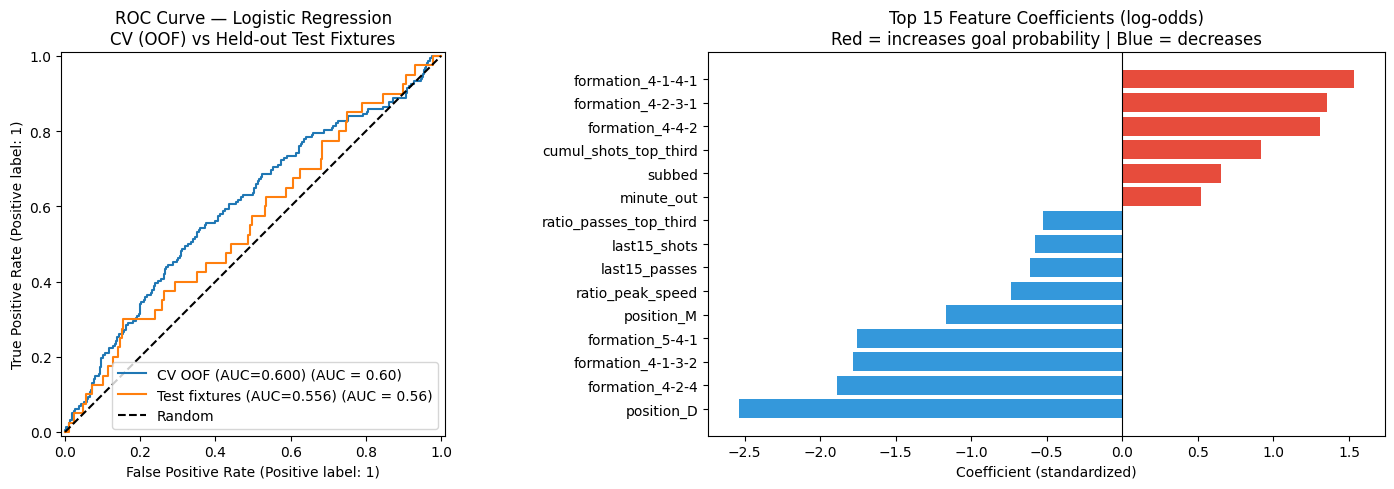

Plot saved to logistic_regression_v3_results.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- ROC Curve: CV (OOF) vs Test ---
RocCurveDisplay.from_predictions(
    y_train, y_prob_oof, ax=axes[0],
    name=f"CV OOF (AUC={auc_cv:.3f})"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_test, ax=axes[0],
    name=f"Test fixtures (AUC={auc_test:.3f})"
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve — Logistic Regression\nCV (OOF) vs Held-out Test Fixtures")
axes[0].legend()

# --- Top 15 coefficient bar chart ---
top15 = coef_df.head(15).sort_values("coefficient")
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top15["coefficient"]]
axes[1].barh(top15["feature"], top15["coefficient"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(
    "Top 15 Feature Coefficients (log-odds)\n"
    "Red = increases goal probability | Blue = decreases"
)
axes[1].set_xlabel("Coefficient (standardized)")

plt.tight_layout()
plt.savefig("logistic_regression_v3_results.png", dpi=150)
plt.show()
print("Plot saved to logistic_regression_v3_results.png")